# Showcase: Mission synthesis (test tailoring)

Combine the fatigue damage of several real-life vibration events into a reference **FDS** (Fatigue Damage Spectrum) and **ERS** (Extreme Response Spectrum), then **invert** the reference FDS into an equivalent, accelerated laboratory test PSD.

Workflow (Lalanne, *Specification Development*, 2009): FDS are **summed** (damage accumulates), ERS are **enveloped** (worst single event), the reference FDS is **inverted** to a test PSD for a chosen test duration, and the test ERS is checked against the reference ERS to guard against over-testing.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import FatigueDS

## 1. Define the life profile as a set of events

Each event is an ordinary `Spectrum` with its own load and duration. All events share the same natural-frequency range and material parameters. The FDS theory uses SI base units, so use `unit='ms2'`.

In [2]:
freq_range = (20, 480, 5)        # shared natural-frequency axis [Hz]
Q = 10                           # quality factor
k, C, p = 7, 1.0, 1.0            # S-N slope, S-N constant, stress/displacement const

# Event 1: road transport - broadband 20-500 Hz, 3 hours
freq1 = np.arange(20, 500, 1.0)
psd1 = np.full_like(freq1, 0.5)  # (m/s^2)^2/Hz
road = FatigueDS.Spectrum(freq_data=freq_range, Q=Q)
road.set_random_load((psd1, freq1), unit='ms2', T=3 * 3600)
road.get_ers()
road.get_fds(k=k, C=C, p=p)

# Event 2: engine running - 150-400 Hz, higher level, 1 hour, occurs 5 times
freq2 = np.arange(150, 400, 1.0)
psd2 = np.full_like(freq2, 2.0)
engine = FatigueDS.Spectrum(freq_data=freq_range, Q=Q)
engine.set_random_load((psd2, freq2), unit='ms2', T=1 * 3600)
engine.get_ers()
engine.get_fds(k=k, C=C, p=p)

## 2. Combine the events

`repeats` is the number of occurrences in the life profile. `combine()` sums the FDS and envelopes the ERS, exposing `ms.fds_ref`, `ms.ers_ref`, `ms.f0_range`.

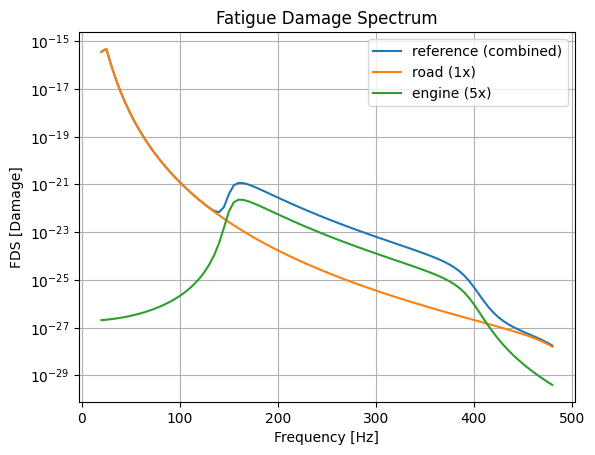

In [3]:
ms = FatigueDS.MissionSynthesis()
ms.add_event(road, repeats=1)
ms.add_event(engine, repeats=5)   # the engine event occurs 5 times
ms.combine()

ms.plot_fds()
road.plot_fds(new_figure=False)
engine.plot_fds(new_figure=False)
plt.legend(['reference (combined)', 'road (1x)', 'engine (5x)'])
plt.show()

## 3. Invert the reference FDS to a test PSD

`invert(T_test)` derives the acceleration PSD reproducing the reference damage over the test duration. A shorter `T_test` gives a higher level (accelerated test). Material parameters default to the event values.

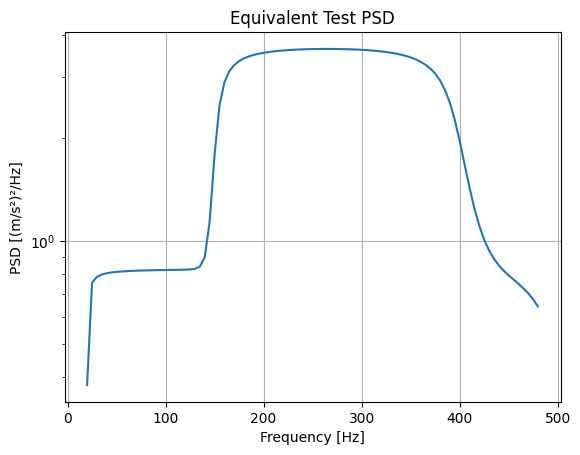

In [4]:
T_test = 30 * 60                 # 30-minute accelerated test [s]
ms.invert(T_test=T_test)

ms.plot_test_psd()
plt.show()

## 4. Over-test guard

`check_ers()` recomputes the ERS of the derived test PSD and compares it to the reference ERS, warning where the accelerated test exceeds the field extreme response.

C:\Users\jasas\Work\OpenSource\FatigueDS\FatigueDS\FatigueDS\mission_synthesis.py:173: UserWarning: test ERS exceeds reference ERS (max ratio 1.65 at 425.0 Hz): possible over-test
  warnings.warn(


max test/reference ERS ratio: 1.649


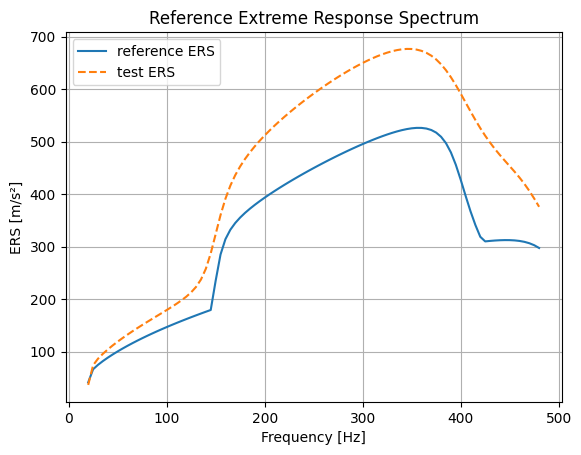

In [5]:
ms.check_ers()
print('max test/reference ERS ratio:', round(float(np.max(ms.ers_ratio)), 3))

ms.plot_ers()
plt.plot(ms.f0_range, ms.ers_test, '--')
plt.legend(['reference ERS', 'test ERS'])
plt.show()